# Notebook 1: Introducción al aprendizaje por refuerzos

Curso Aprendizaje por Refuerzos, Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones

Facultad de Matemática, Astronomía, Física y Computación, Universidad Nacional de Córdoba

## Estudiante: Gonzalo Angaut, Grupo 18

## Introducción

En el siguiente notebook se muestra cómo ejecutar agentes de aprendizaje por refuerzos, los cuáles son necesarios para realizar este Lab.

### Repaso rápido



* Recompensa: señal $r$ recibida desde el entorno que recompensa o castiga el agente según su desempeño con respecto al objetivo de la tarea.

* Valor: función $v_\pi (s)$ que establece cuánto el agente espera percibir de recompensa al seguir la política $\pi$ partiendo desde el estado $s$. También se la suele expresar como $Q_\pi(s,a)$, indicando cuánto el agente espera percibir siguiendo la política $\pi$ partiendo desde el estado $s$ y siguiendo la acción $a$.

* Política: función $\pi(s) \to a$ que mapea un estado a una acción. Se suele expresar como probabilidad de elegir la acción $\pi(a \mid s)$. La política $\epsilon$-greedy, en donde $\epsilon$ es la probabilidad de exploración (normalmente menor que la probabilidad de explotación) está dada por $\pi(a \mid s) = 1 - \epsilon$ si $a$ es la mejor acción, caso contrario pasa a estar dada por $\pi(a \mid s) = \epsilon$.

Por otra parte, en la política Softmax, no se busca la acción con máxima probabilidad sino que se computa la probabilidad de cada una mediante la función Softmax y se realiza un sorteo entre ellas pesado por la misma. Así, para cada acción $a$, $$\pi(a \mid s) = \frac{e^{Q(s,a)/\tau}}{\sum_{\widetilde{a} \in A}e^{Q(s,\widetilde{a})/\tau}}$$

En este notebook vemos dos algoritmos para actualizar la función de valor (y, por lo tanto, la política de selección de acciones):

* Actualización por SARSA (on-policy).

$$Q(s,a) \gets Q(s,a) + \alpha (r + \gamma Q(s',a') - Q(s,a))$$

Algoritmo completo (a modo de referencia):

![Algoritmo SARSA](https://github.com/DiploDatos/AprendizajePorRefuerzos/blob/master/images/sarsa.png?raw=1)


* Actualización por Q-Learning (off-policy)

$$Q(s,a) \gets Q(s,a) + \alpha (r + \gamma \arg\max_{a'} Q(s',a') - Q(s,a))$$

Algoritmo completo (a modo de referencia):

![Algoritmo Q-Learning](https://github.com/DiploDatos/AprendizajePorRefuerzos/blob/master/images/q_learning.png?raw=1)

Fuente de las imágenes: capítulo 6 de [Reinforcement Learning: An Introduction](http://www.incompleteideas.net/book/the-book.html).

## Librería a usar: Gymnasium (sucesora de OpenAI Gym)

[Gymnasium](https://github.com/Farama-Foundation/Gymnasium), es la librería que continúa con [OpenAI Gym](https://gym.openai.com/) (Brockman et. al., 2016), famosa librería de OpenAI que ofrece entornos y una interfaz estándar con la cuál probar nuestros agentes. Su objetivo es proveer benchmarks unificados para ver el desempeño de algoritmos en el entorno y así poder saber con facilidad cómo es su desempeño comparado con los demás. Parte de la siguiente sección está basada en la [documentación oficial de OpenAI](https://gym.openai.com/docs/).

La interfaz principal de los ambientes de gym es la interfaz Env. La misma posee cinco métodos principales:

* ```reset(self, seed)``` : Reinicia el estado del entorno, a su estado inicial, devolviendo una observación de dicho estado. Opcionalmente, establece la semilla aleatoria del generador de números aleatorios del presente entorno.

* ```step(self, action)``` : "Avanza" un timestep del ambiente. Devuelve: ```observation, reward, terminated, truncated, info```.

* ```render(self)``` : Muestra en pantalla una parte del ambiente.

* ```close(self)``` : Finaliza con la instancia del agente.


Por otra parte, cada entorno posee los siguientes tres atributos principales:

* ```action_space``` : El objeto de tipo Space correspondiente al espacio de acciones válidas.

* ```observation_space``` : El objeto de tipo Space correspondiente a todos los rangos posibles de observaciones.

* ```reward_range``` : Tupla que contiene los valores mínimo y máximo de recompensa posible.

Algunas de las ejecuciones contienen videos. Para poder verlos se necesita previamente instalar la librería ffmpeg; para instalarla desde Linux ejecutar en consola

```apt-get install ffmpeg```

desde Mac, reemplazar *apt-get* por *brew*

desde Windows, descargarla desde

[https://ffmpeg.org/download.html](https://ffmpeg.org/download.html)

(Nota: las animaciones son a modo ilustrativo, si no se desea instalar la librería se puede directamente eliminar la línea de código donde se llama al método ``env.render(mode='human')``)

Código básico de importación y funciones de graficación (no modificar)

In [1]:
# @title Código básico importacion y utilerías (no modificar)

import itertools
from typing import Any, Callable, Tuple

import numpy as np
import matplotlib.pyplot as plt

def plot_reward_per_episode(reward_ep, ax=None, label=None) -> None:
    episode_rewards = np.array(reward_ep)

    # se suaviza la curva de convergencia
    episode_number = np.linspace(
        1, len(episode_rewards) + 1, len(episode_rewards) + 1)
    acumulated_rewards = np.cumsum(episode_rewards)

    reward_per_episode = [
        acumulated_rewards[i] / episode_number[i]
        for i in range(len(acumulated_rewards))
    ]

    # Si no se pasa ax, creamos la figura como antes
    if ax is None:
        plt.plot(reward_per_episode)
        plt.title("Recompensa acumulada por episodio")
        plt.show()
    else:
        ax.plot(reward_per_episode, label=label)
        if label is not None:
            ax.legend()
        ax.set_title("Recompensa acumulada por episodio")

def plot_steps_per_episode(timesteps_ep, ax=None, label=None) -> None:
    episode_steps = np.array(timesteps_ep)

    # si no se pasó un axis, creamos uno
    if ax is None:
        _, ax = plt.subplots(figsize=(7,4))

    ax.plot(
        np.arange(len(episode_steps)),
        episode_steps,
        label=label
    )

    ax.set_title("Pasos (timesteps) por episodio")

    # solo mostramos la leyenda si hay labels
    if label is not None:
        ax.legend()

    # sólo mostramos si no nos pasaron un ax externo
    if ax is None:
        plt.show()

def plot_steps_per_episode_smooth(timesteps_ep, ax=None, label=None) -> None:
    episode_steps = np.array(timesteps_ep)

    # se suaviza la curva de aprendizaje
    episode_number = np.linspace(
        1, len(episode_steps) + 1, len(episode_steps) + 1)
    acumulated_steps = np.cumsum(episode_steps)

    steps_per_episode = [
        acumulated_steps[i] / episode_number[i]
        for i in range(len(acumulated_steps))
    ]

    # si no se pasó un axis, creamos uno
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))
        created_ax = True

    ax.plot(steps_per_episode, label=label)
    ax.set_title("Pasos (timesteps) acumulados por episodio")

    if label is not None:
        ax.legend()

    if created_ax:
        plt.show()

def draw_value_matrix(q, ax=None):
    n_rows = 4
    n_columns = 12
    n_actions = 4

    # --- Crear ax si no viene de afuera ---
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
        created_ax = True

    # se procede con los cálculos previos a la graficación de la matriz de valor
    q_value_matrix = np.empty((n_rows, n_columns))
    for row in range(n_rows):
        for column in range(n_columns):
            state_values = []
            for action in range(n_actions):
                state_values.append(
                    q.get((row * n_columns + column, action), -100)
                )
            maximum_value = max(state_values)
            q_value_matrix[row, column] = maximum_value

    # valor del objetivo
    q_value_matrix[3, 11] = -1

    # --- usar ax.imshow en lugar de plt.imshow ---
    im = ax.imshow(q_value_matrix, cmap=plt.cm.RdYlGn)

    if created_ax:
        plt.colorbar(im, ax=ax)

    # --- dibujar flechas (casi sin cambios, solo reemplazo plt → ax) ---
    for row, column in itertools.product(
        range(q_value_matrix.shape[0]), range(q_value_matrix.shape[1])
    ):
        left_action = q.get((row * n_columns + column, 3), -1000)
        down_action = q.get((row * n_columns + column, 2), -1000)
        right_action = q.get((row * n_columns + column, 1), -1000)
        up_action = q.get((row * n_columns + column, 0), -1000)

        arrow_direction = "D"
        best_action = down_action

        if best_action < right_action:
            arrow_direction, best_action = "R", right_action
        if best_action < left_action:
            arrow_direction, best_action = "L", left_action
        if best_action < up_action:
            arrow_direction, best_action = "U", up_action

        # estado terminal
        if row == n_rows - 1 and column == n_columns - 1:
            arrow_direction = ""

        ax.text(column, row, arrow_direction,
                ha="center", va="center")

    ax.set_xticks([])
    ax.set_yticks([])

    if created_ax:
        plt.tight_layout()
        plt.show()
        print("\n Matriz de mejor acción-valor (en números): \n\n", q_value_matrix)

    return ax

Ejemplo: agente CartPole

In [2]:
from IPython.display import clear_output
import importlib.util

if importlib.util.find_spec("google.colab") is not None:
    IN_COLAB = True
    %pip install gymnasium
else:
    IN_COLAB = False

import gymnasium as gym

# no es posible mostrar videos de ejecución del agente desde Colab
if not IN_COLAB:

    env = gym.make('CartPole-v0')
    env.reset()
    env.render()

    for _ in range(500):
        env.render()
        # se ejecuta una acción aleatoria
        obs, reward, terminated, truncated, info = env.step(
           env.action_space.sample())

        done = terminated or truncated
        if done:
            env.reset()
    env.close()
    clear_output()

Ejemplo: agente Mountain Car

In [3]:
if not IN_COLAB:
    env = gym.make('MountainCar-v0')
    obs = env.reset()
    for t in range(500):
        env.render()
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        if done:
            print("Episode finished after {} timesteps".format(t+1))
            break
    env.close()
    clear_output()

## Ejemplo 1: The Cliff.


![](https://github.com/GIDISIA/RLDiplodatos/blob/master/images/cliffwalking.png?raw=1)

donde S= starting point, G= goal

(imagen de Sutton y Barto, 2018)

Descripción del entorno:

Acciones:

* $\uparrow$ - Arriba
* $\downarrow$ - Abajo
* $\rightarrow$ - Derecha
* $\leftarrow$ - Izquierda

Función de recompensa:

* $-1$ en todos los demás estados
* $-100$ en el acantilado

Nota: caer en el acantilado devuelve al agente al estado inicial en un mismo episodio

Vemos los bloques básicos de nuestro agente

Definimos el método de elección de acciones. En este caso el mismo utiliza la política de exploración $\epsilon$-greedy.

In [4]:
def choose_action_e_greedy(
        state: int,
        actions: range,
        q: dict,
        hyperparameters: dict,
        random_state: np.random.RandomState,
) -> int:
    """
    Elije una acción de acuerdo al aprendizaje realizado previamente
    usando una política de exploración épsilon-greedy
    """
    # ej: para 4 acciones inicializa en [0,0,0,0]
    q_values = [q.get((state, a), 0.0) for a in actions]
    max_q = max(q_values)
    # sorteamos un número: es menor a épsilon?
    if random_state.uniform() < hyperparameters['epsilon']:
        # sí: se selecciona una acción aleatoria
        return random_state.choice(actions)

    count = q_values.count(max_q)

    # hay más de un máximo valor de estado-acción?
    if count > 1:
        # sí: seleccionamos uno de ellos aleatoriamente
        best = [i for i in range(len(actions)) if q_values[i] == max_q]
        i = random_state.choice(best)
    else:
        # no: seleccionamos el máximo valor de estado-acción
        i = q_values.index(max_q)

    return actions[i]

In [5]:
def choose_action_softmax() -> int:
    """
    Elije una acción de acuerdo al aprendizaje realizado previamente
    usando una política softmax
    """

    # TODO: implementar
    pass

Definimos el esqueleto del método learn, el cuál toma una transición y cambia el dict de los valores de Q de acuerdo a algún algoritmo.

In [6]:
def learn_SARSA(
        state: Any, # COMPLETAR tipo de cada parámetro
        action: Any,
        reward: Any,
        next_state: Any,
        next_action: Any,
        hyperparameters: Any,
        q: Any,
) -> None:
    """
    Realiza una actualización según el algoritmo SARSA, para una transición
    de estado dada
    Args:
        state: COMPLETAR
        action: COMPLETAR
        reward: COMPLETAR
        next_state: COMPLETAR
        next_action: COMPLETAR
        hyperparameters: COMPLETAR
        q: COMPLETAR
    """

    # TODO - completa con tu código aquí

    pass

In [7]:
# completar argumentos de la función para hacer una actualización Q-learning
def learn_Q_learning(
        # COMPLETAR
) -> None:
    """
    Realiza una actualización según el algoritmo Q-learning, para una transición
    de estado dada
    Args: COMPLETAR
    """

    # TODO - completa con tu código aquí

    pass

Finalmente, definimos el método principal de iteraciones.

In [8]:
def run(
    learning_function: Callable,
    hyperparameters: dict,
    episodes_to_run: int,
    env: gym.Env,
    actions: range,
    q: dict,
    random_state: np.random.RandomState,
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Corre el algoritmo de RL para el ambiente FrozenLake-v0.
    Args:
        learning_function: función de actualización de algoritmo de aprendizaje
        hyperparameters: hiperparámetros del algoritmo de aprendizaje
        episodes_to_run: cantidad de episodios a ejecutar
        env: ambiente de Gymnasium
        actions: lista de acciones posibles
        q: diccionario de valores de estado-acción
        random_state: generador de números aleatorios
    """
    # registro de la cantidad de pasos que le llevó en cada episodio
    # llegar a la salida
    timesteps_of_episode = []
    # cantidad de recompensa que recibió el agente en cada episodio
    reward_of_episode = []

    for _ in range(episodes_to_run):
        # se ejecuta una instancia del agente hasta que el mismo
        # llega a la salida o tarda más de 2000 pasos

        # reinicia el ambiente, obteniendo el estado inicial del mismo
        state, _ = env.reset()

        episode_reward = 0
        done = False
        t = 0

        # elige una acción basado en el estado actual.
        # Filtra el primer elemento de state, que es el estado en sí mismo
        action = choose_action_e_greedy(
            state, actions, q, hyperparameters, random_state)

        while not done:
            # el agente ejecuta la acción elegida y obtiene los resultados
            next_state, reward, terminated, truncated, _ = env.step(action)

            next_action = choose_action_e_greedy(
                next_state, actions, q, hyperparameters, random_state)

            episode_reward += reward
            learning_function(
                state,
                action,
                reward,
                next_state,
                next_action,
                hyperparameters,
                q
            )

            done = terminated or truncated

            # if the algorithm does not converge, it stops after 2000 timesteps
            if not done and t < 2000:
                state = next_state
                action = next_action
            else:
                # el algoritmo no ha podido llegar a la meta antes de dar 2000 pasos
                done = True  # se establece manualmente la bandera done
                timesteps_of_episode = np.append(timesteps_of_episode, [int(t + 1)])
                reward_of_episode = np.append(
                    reward_of_episode, max(episode_reward, -100)
                )

            t += 1

    return reward_of_episode.mean(), timesteps_of_episode, reward_of_episode

Definidos los métodos básicos, procedemos a instanciar a nuestro agente.

In [9]:
# se crea el diccionario que contendrá los valores de Q
# para cada tupla (estado, acción)
q = {}

# definimos sus híper-parámetros básicos
hyperparameters = {
    "alpha": 0.5,
    "gamma": 1,
    "epsilon": 0.1,
    "tau": 25,
}


# se puede cambiar por learn_Q_learning, una vez que se implemente
learning_function = learn_SARSA
episodes_to_run = 500

env = gym.make("CliffWalking-v1")
actions = range(env.action_space.n)

# se declara una semilla aleatoria
random_state = np.random.RandomState(42)

Ya instanciado, ejecutamos nuestro agente

In [10]:
avg_steps_per_episode, timesteps_ep, reward_ep = run(
    learning_function,
    hyperparameters,
    episodes_to_run,
    env,
    actions,
    q,
    random_state
)

### Análisis de la ejecución del agente

#### Análisis de convergencia

A diferencia de lo que sucede en el aprendizaje supervisado, en el aprendizaje por refuerzos el rendimiento se evalúa por una función específica que es la función de recompensa. En la práctica, la función de recompensa puede ser externa (y provista por el entorno) o bien puede ser una función creada por diseño (a modo de dirigir el agente hacia lo que por diseño se considera mejor, en nuestro ejemplo podría ser con una recompensa de $+1$ cada vez que el agente llega al estado objetivo). Esto se conoce como *reward shaping*, y hay que tener mucho cuidado con los posibles efectos secundarios de su uso.

Como el objetivo de RL es maximizar la recompensa obtenida, es posible utilizar la información sobre la obtención de la recompensas en cada time-step o episodio para evaluar el rendimiento parcial del agente (esto depende mucho de la particularidad de la distribución de la recompensa para el problema tratado).

Para analizar la ejecución del agente, vamos a ver cómo se desempeñó el mismo en dos curvas:

* Recompensa obtenida en cada episodio: nos dirá cuánta recompensa obtuvo el agente sumando cada una de recompensas individuales de cada episodio. Con esta medida podremos tener una noción de cómo se desempeñó esquivando el acantilado y llegando lo antes posible a la meta.

* Pasos transcurridos en cada episodio: indicará cuántos pasos le ha llevado al agente la ejecución del episodio.

Se estila suavizar ambas curvas para apreciar mejor su progresión (aunque a veces suele analizarse la curva de pasos por episodio sin suavizar).

Veamos recompensa por episodio (recordar que en este entorno cada paso otorga una recompensa de $-1$ excepto al caer al acantilado, donde la recompensa es de $-100$)

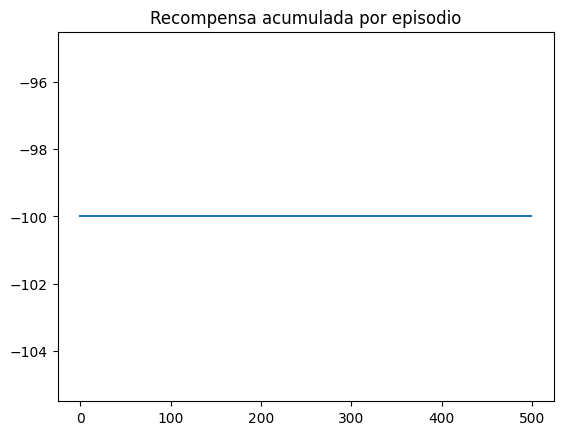

In [11]:
plot_reward_per_episode(reward_ep)

Veamos pasos por episodio

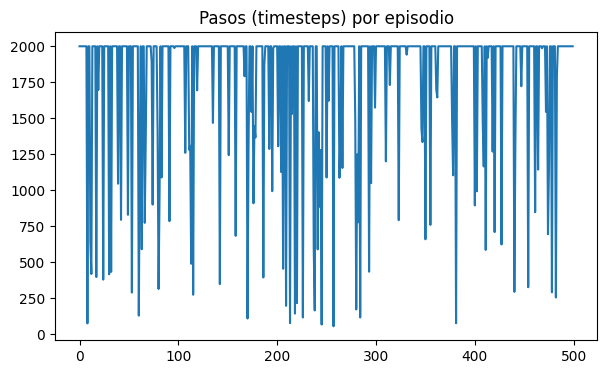

In [12]:
plot_steps_per_episode(timesteps_ep)

Suavizando...

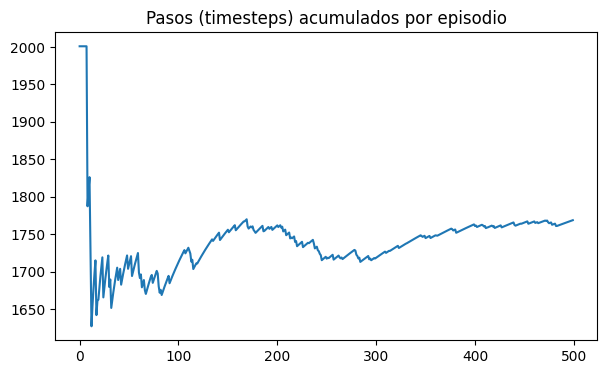

In [13]:
plot_steps_per_episode_smooth(timesteps_ep)

#### Análisis de matriz de acción-valor y política óptima

Siendo que este es un ejemplo tabular y de pocos estados / acciones, es posible realizar un análisis de convergencia desde otro punto de vista: desde el valor de la función $Q(s,a)$ para la mejor acción de cada estado, al finalizar el entrenamiento del agente, (sería la acción que el agente ejecutaría en cada estado bajo una política *greedy*). Ambos nos brindarán información sobre la convergencia alcanzada por el agente.

Tener en cuenta que este análisis se hace principalmente con fines educativos, para entornos más complejos el mismo puede no ser factible. En tales casos, un análisis alternativo podría consistir en hacer que el agente ejecute su política para la que fue entrenado, para hacer una evaluación a partir del comportamiento del mismo (esto último sería el *test de la política*, frente al *entrenamiento de la política* previo).

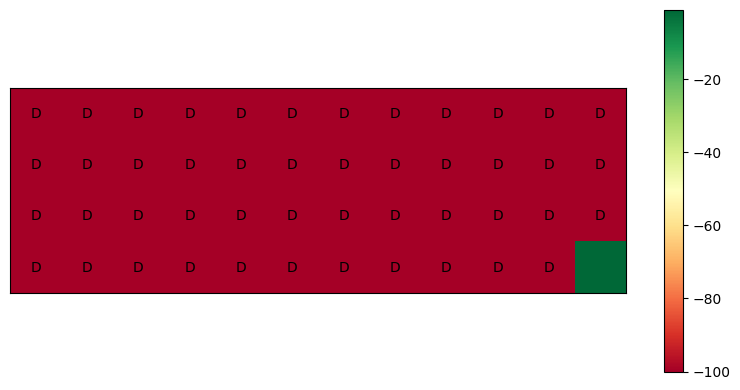


 Matriz de mejor acción-valor (en números): 

 [[-100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100.]
 [-100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100.]
 [-100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100.]
 [-100. -100. -100. -100. -100. -100. -100. -100. -100. -100. -100.   -1.]]


<Axes: >

In [14]:
draw_value_matrix(q)

In [15]:
env.close()

## Actividades

1. Implementar y ejecutar el algoritmo SARSA en "The Cliff".

2. Implementar y ejecutar el algoritmo Q-Learning en "The Cliff". ¿Cómo converge con respecto a SARSA? ¿A qué se debe? Comentar.

3. Ejecutando con distintos híper-parámetros, realizar una breve descripción sobre cómo afectan a la convergencia los distintos valores de $\alpha$, $\epsilon$ y $\gamma$.

4. (Opcional) Implementar política de exploración Softmax, en donde cada acción tiene una probabilidad $$\pi(a \mid s) = \frac{e^{Q(s,a)/\tau}}{\sum_{\widetilde{a} \in A}e^{Q(s,\widetilde{a})/\tau}}$$

5. (Opcional) Implementar Dyna-Q a partir del algoritmo Q-Learning, incorporando una actualización mediante un modelo. Comentar cómo se desempeña respecto a los demás algoritmos.


Para dejar el lab listo para su corrección, dejar link a repo de Github con un notebook ejecutando el agente en la planilla enviada en Slack.

En este trabajo, debemos completar las funciones dadas. Vamos a reescribirlas acá (completándolas) acá asi no desaparece el flujo de trabajo previo.

1. Comencemos con la función para implementar SARSA. Para eso, recordemos que esta actualización es on-policy y está dada por:

$$Q(s,a) \gets Q(s,a) + \alpha (r + \gamma Q(s',a') - Q(s,a))$$

In [16]:
def learn_SARSA(
        state: int,
        action: int,
        reward: float,
        next_state: int,
        next_action: int,
        hyperparameters: dict,
        q: dict,
) -> None:
    """
    Realiza una actualización según el algoritmo SARSA, para una transición
    de estado dada

    Args:
        state (int):
            Estado actual del agente antes de tomar la acción.
        action (int):
            Acción tomada en el estado actual.
        reward (float):
            Recompensa inmediata recibida después de tomar la acción en este
            estado.
        next_state (int):
            Estado resultante tras ejecutar la acción.
        next_action (int):
            Acción seleccionada en el siguiente estado.
        hyperparameters (dict):
            Diccionario con hiperparámetros del algoritmo:
        q (dict):
            Diccionario que almacena los valores Q. Las claves son tuplas `(state, action)`
            y los valores son números flotantes que representan Q(s,a).

    """
    # Definimos los hiperparámetros necesarios
    alpha = hyperparameters["alpha"]
    gamma = hyperparameters["gamma"]

    # Tomamos los valores de q. Si no existen, entonces que valgan 0.0
    # Valor de q actual (Q(s,a))
    current_q = q.get((state, action), 0.0)
    # Valor de q en el paso siguiente (Q(s',a')) según la política
    next_q = q.get((next_state, next_action), 0.0)

    # Actualizamos el valor de q
    q[(state, action)] = current_q + alpha * (reward + gamma * next_q - current_q)

    pass

Una vez definida la función, podemos instanciar nuestro agente. Para eso, usamos la función definida previamente `run` y definiendo los hiperparámetros que queramos utilizar

In [17]:
# se crea el diccionario que contendrá los valores de Q
# para cada tupla (estado, acción)
q = {}

# definimos sus híper-parámetros básicos
hyperparameters = {
    "alpha": 0.5,
    "gamma": 1,
    "epsilon": 0.1,
    "tau": 25, # SARSA no lo usa pero lo dejamos
}


# Elegimos como función a SARSA
learning_function = learn_SARSA
episodes_to_run = 2000

env = gym.make("CliffWalking-v1")
actions = range(env.action_space.n)

# se declara una semilla aleatoria
random_state = np.random.RandomState(42)

Ahora que ya está instanciado, lo ejecutamos:

In [18]:
avg_steps_per_episode, timesteps_ep, reward_ep = run(
    learning_function,
    hyperparameters,
    episodes_to_run,
    env,
    actions,
    q,
    random_state
)

Veamos la recompensa acumulada por episodio que

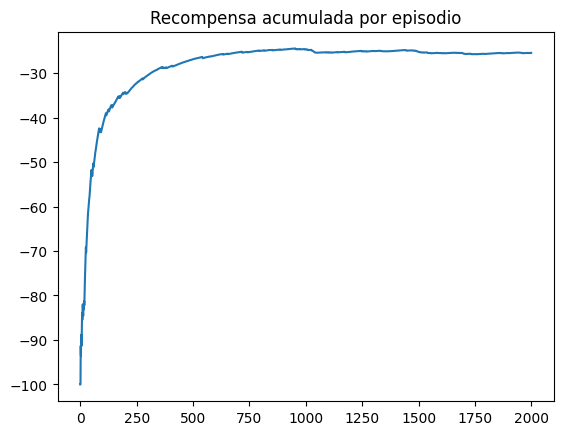

In [19]:
plot_reward_per_episode(reward_ep)

Al inicio del entrenamiento, la recompensa obtenida por episodio es muy baja (≈ −100), lo cual es esperable porque el agente cae por el “cliff” repetidamente mientras explora.

A medida que aprende, las recompensas empiezan a aumentar y eventualmente se estabilizan alrededor de un valor cercano a −30. Esta meseta indica que el agente está siguiendo una política estable, evitando el precipicio.

El hecho de que la recompensa acumulada por episodio alcance un valor estacionario muestra que el algoritmo ha convergido hacia una política consistente.

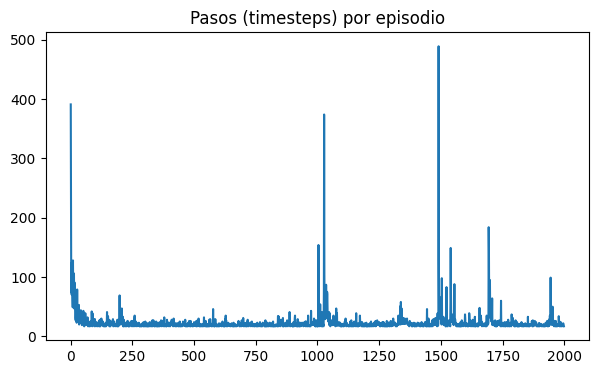

In [20]:
plot_steps_per_episode(timesteps_ep)

Podemos ver que al comienzo el agente necesita muchos pasos para llegar al objetivo. Esto se debe a que inicialmente no tiene información sobre el entorno y explora acciones que pueden no ser convenientes. A medida que aprende, el número de pasos disminuye, lo que indica que la política aprendida mediante SARSA se está volviendo cada vez más eficiente.

Los picos ocasionales pueden deberse a que el agente continúa explorando debido a la política. Si suavizamos la curva, puede verse mejor como estabiliza:

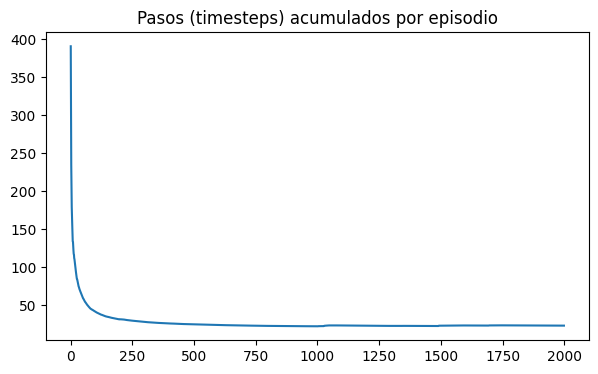

In [21]:
plot_steps_per_episode_smooth(timesteps_ep)

Por último, podemos ver un matriz de acción-valor

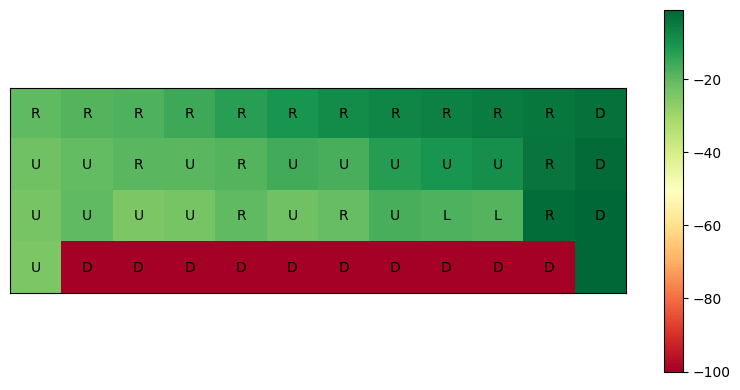


 Matriz de mejor acción-valor (en números): 

 [[ -20.14576413  -18.74323745  -17.94836622  -15.51293673  -12.76930709
   -10.56708351   -8.57327744   -7.22158389   -6.37053214   -5.52322137
    -4.34697675   -3.08670353]
 [ -22.43706292  -20.59562506  -19.27095528  -19.54827595  -18.5430603
   -16.29443127  -17.09120264  -12.28279812  -10.32208512   -9.4121788
    -3.99616835   -2.00000124]
 [ -23.75953398  -20.08707052  -24.33836794  -23.69672627  -20.03427147
   -22.39541537  -20.81126349  -16.85708246  -17.66582055  -18.55774698
    -2.53772953   -1.        ]
 [ -24.39230823 -100.         -100.         -100.         -100.
  -100.         -100.         -100.         -100.         -100.
  -100.           -1.        ]]


<Axes: >

In [22]:
draw_value_matrix(q)

Podemos ver que en aplicando el algoritmo SARSA, si empezamos del comienzo y tomamos todas las decisiones basadas en la mejor dirección, el camino final corresponde a subir alejandose del "cliff" para luego ir por arriba hacia la derecha y luego bajar hacia el objetivo. Este no es el camino óptimo en cuanto a distancia recorrida pero sí el más seguro. Esto se debe a que, como en la política utilizada todavía hay exploración, en los casos en los que se acerca por el "cliff" puede caerse y eso castiga mucho.  

2. Implementemos ahora el algoritmo de Q-learning. Para eso, comencemos definiendo la función:

In [23]:
def learn_Q_learning(
        state: int,
        action: int,
        reward: float,
        next_state: int,
        next_action: int,  # No usa pero por compatibilidad
        hyperparameters: dict,
        q: dict,
) -> None:
    """
    Realiza una actualización según el algoritmo Q-learning, para una transición
    de estado dada
    Args:
        state (int):
            Estado actual del agente antes de tomar la acción.
        action (int):
            Acción tomada en el estado actual.
        reward (float):
            Recompensa inmediata recibida después de tomar la acción en este
            estado.
        next_state (int):
            Estado resultante tras ejecutar la acción.
        next_action (int):
            Acción seleccionada en el siguiente estado.
        hyperparameters (dict):
            Diccionario con hiperparámetros del algoritmo:
        q (dict):
            Diccionario que almacena los valores Q. Las claves son tuplas `(state, action)`
            y los valores son números flotantes que representan Q(s,a).
    """
    # Definimos los hiperparámetros necesarios
    alpha = hyperparameters["alpha"]
    gamma = hyperparameters["gamma"]
    # Las acciones posibles también las tomamos como hiperparámetro
    actions = hyperparameters["actions"]

    # Tomamos solamente el valor de la celda actual de q. Si no existe, le
    # asignamos el valor 0.0
    current_q = q.get((state, action), 0.0)

    # Tomamos el valor máximo de los q's posibles
    next_q_values = [q.get((next_state, a), 0.0) for a in actions]
    max_next_q = max(next_q_values)

    # Actualizamos el valor de q
    q[(state, action)] = current_q + alpha * (reward + gamma * max_next_q - current_q)
    pass

Ahora instanciemos el agente:

In [24]:
env = gym.make("CliffWalking-v1")
actions = range(env.action_space.n)

# se crea el diccionario que contendrá los valores Q
q = {}

# definimos sus híper-parámetros básicos
hyperparameters = {
    "alpha": 0.5,
    "gamma": 1.0,
    "epsilon": 0.1,
    "tau": 25,
    "actions": actions
}

learning_function = learn_Q_learning
episodes_to_run = 2000

# semilla aleatoria
random_state = np.random.RandomState(42)

Ahora que ya está instanciado, lo ejecutamos:

In [25]:
avg_steps_per_episode, timesteps_ep, reward_ep = run(
    learning_function,
    hyperparameters,
    episodes_to_run,
    env,
    actions,
    q,
    random_state
)

Veamos la recompensa acumulada por episodio que

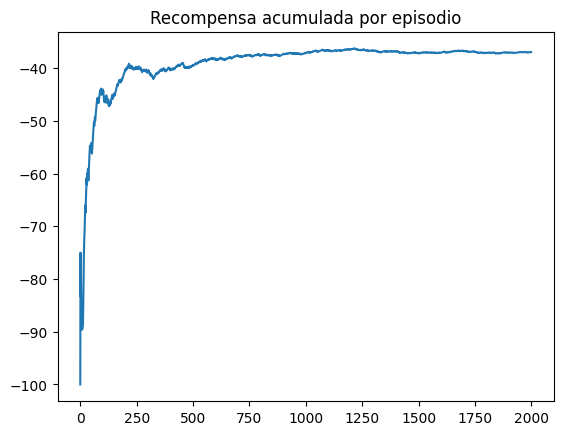

In [26]:
plot_reward_per_episode(reward_ep)

Al igual que antes, observamos que al comienzo la recompensa acumulada era muy baja pero luego va aumentando hasta alcanzar un valor estacionario. En este caso, el valor estable es aproximadamente −40, que es más bajo que el obtenido con SARSA.

Esto puede deberse a que Q-learning tiende a aprender la política óptima incluso si eso implica seguir rutas más riesgosas que pasan cerca del acantilado. Como consecuencia, durante el aprendizaje es más probable que el agente ‘caiga’ y reciba recompensas muy negativas, lo cual baja la recompensa acumulada promedio.

Veamos los pasos por episodio:

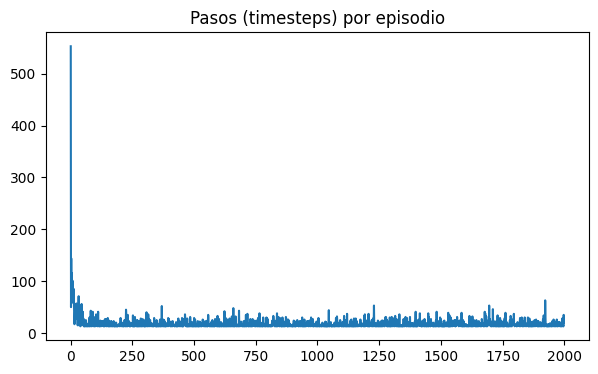

In [27]:
plot_steps_per_episode(timesteps_ep)

Notemos que en este caso, al comienzo el agente necesita más pasos pero se estabiliza rápidamente y no se observan tanto los picos como antes. Esto puede suceder ya que si ahora explora, como pasa cerca del acantilado muchas veces cae y no sigue un camino muy largo.

Si suavizamos la curva, puede verse mejor como estabiliza:

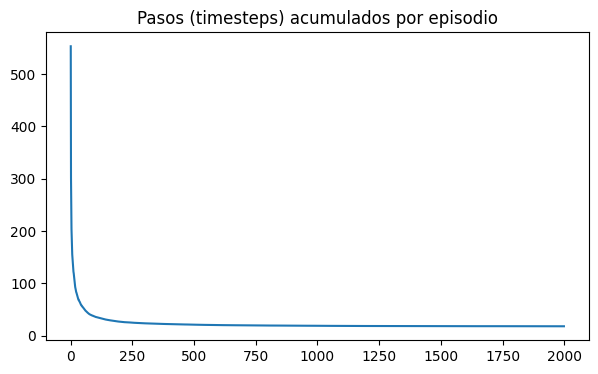

In [28]:
plot_steps_per_episode_smooth(timesteps_ep)

Por último, podemos ver un matriz de acción-valor

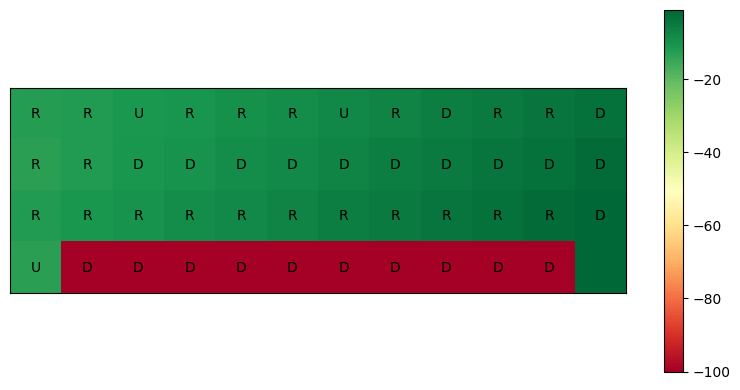


 Matriz de mejor acción-valor (en números): 

 [[ -12.45517146  -12.10407031  -11.25793028  -10.61284086   -9.70576525
    -8.81809504   -7.89541487   -6.96220743   -5.97849011   -4.98797681
    -3.9945674    -2.99999187]
 [ -13.          -12.          -11.          -10.           -9.
    -8.           -7.           -6.           -5.           -4.
    -3.           -2.        ]
 [ -12.          -11.          -10.           -9.           -8.
    -7.           -6.           -5.           -4.           -3.
    -2.           -1.        ]
 [ -13.         -100.         -100.         -100.         -100.
  -100.         -100.         -100.         -100.         -100.
  -100.           -1.        ]]


<Axes: >

In [29]:
draw_value_matrix(q)

Notemos que en este caso, si comenzamos desde la esquina inferior izquierda, el camino óptimo es pasar cerca del acantilado hasta el final. Este seguramente es el camino con mejor recompensa, pero también es un camino riesgoso si hay exploración.

3. Ahora veamos cómo dependen los algoritmos de los hiperparámetros $\alpha$, $\gamma$ y $\epsilon$. Para esto, podemos definir una función que instancie el agente y lo ejecute dependiendo el modelo y los parámetros.

In [30]:
def instanciate_agent(alpha, gamma, epsilon, learning_function):
  env = gym.make("CliffWalking-v1")
  actions = range(env.action_space.n)
  # se crea el diccionario que contendrá los valores Q
  q = {}

  # definimos sus híper-parámetros básicos
  hyperparameters = {
      "alpha": alpha,
      "gamma": gamma,
      "epsilon": epsilon,
      "tau": 25,
      "actions": actions
  }

  episodes_to_run = 2000

  # semilla aleatoria
  random_state = np.random.RandomState(42)

  avg_steps_per_episode, timesteps_ep, reward_ep = run(
      learning_function,
      hyperparameters,
      episodes_to_run,
      env,
      actions,
      q,
      random_state
  )

  return avg_steps_per_episode, timesteps_ep, reward_ep, q

Una vez creada, veamos primero cómo los distintos parámetros a SARSA.

Observemos qué sucede al cambiar el parámetro $\alpha$, pero manteniendo $\gamma = 1.0$ y $\epsilon= 0.1$.

Antes de ver cómo cambian los gráficos, es importante saber que $\alpha$ es la tasa de aprendizaje, por lo que un $\alpha$ bajo significa que el aprendizaje es lento pero también estable. El agente puede tomar mucho tiempo en aprender pero es más robusto al ruido. Por otro lado, un $\alpha$ alto implica que el aprendizaje es rápido pero inestable ya que cada nueva experiencia tiene un impacto muy fuerte.

Elijamos los $\alpha$ a utilizar e instanciemos y ejecutemos el agente:

In [31]:
alphas = [0.1, 0.5, 0.9]

# Creamos un diccionario para guardar todos los resultados
results = {}

for alpha in alphas:
    avg_steps, timesteps_ep, reward_ep, q = instanciate_agent(
        alpha=alpha,
        gamma=1.0,
        epsilon=0.1,
        learning_function=learn_SARSA
    )
    results[alpha] = {
        "avg_steps": avg_steps,
        "timesteps": timesteps_ep,
        "reward": reward_ep,
        "q": q
    }

Ahora, grafiquemos la recompensa acumulada. Nota: Para esto, debimos modificar las funciones de graficar.

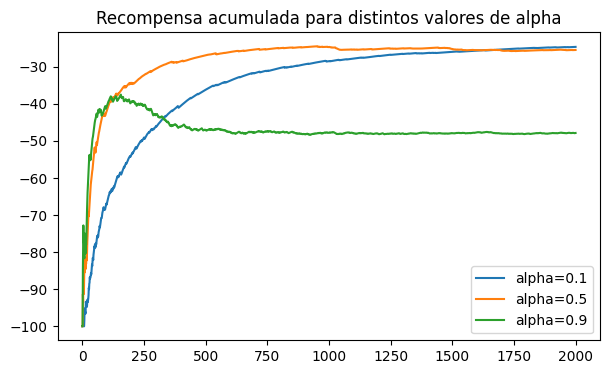

In [32]:
fig, ax = plt.subplots(figsize=(7,4))

for alpha in alphas:
    reward_ep = results[alpha]["reward"]
    # graficamos sobre el mismo eje
    plot_reward_per_episode(reward_ep, ax=ax, label=f"alpha={alpha}")

ax.set_title("Recompensa acumulada para distintos valores de alpha")
plt.show()


Acá podemos ver cómo cuando la tasa de aprendizaje es alta, la recompensa sube rápido al comienzo y al bajar el $\alpha$, este crecimiento se hace más lento. Sin embargo, también se puede observar que la recompensa final para el caso de la tasa de aprendizaje más alta es la menor.

Veamos ahora los pasos por episodio.

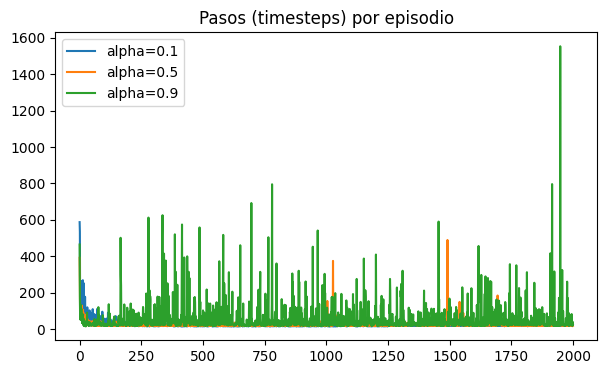

In [33]:
fig, ax = plt.subplots(figsize=(7,4))

for alpha in alphas:
    timesteps_ep = results[alpha]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode(
        timesteps_ep,
        ax=ax,
        label=f"alpha={alpha}"
    )

plt.show()


Acá también podemos ver que cuando la tasa de aprendizaje es muy alta, hay mucha inestabilidad. Esto se debe a que como la política cambia mucho entre episodios, los pasos necesarios para llegar a la meta suben y bajan violentamente. Veamos estas curvas suavizadas:

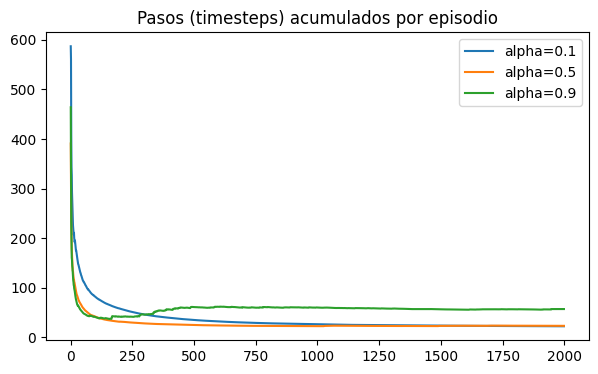

In [34]:
fig, ax = plt.subplots(figsize=(7,4))

for alpha in alphas:
    timesteps_ep = results[alpha]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode_smooth(
        timesteps_ep,
        ax=ax,
        label=f"alpha={alpha}"
    )

plt.show()


Podemos ver que para $\alpha=0.1$ y $\alpha=0.5$ los pasos parecen tender a 0 mientras que para $\alpha=0.9$ no.

Por último, veamos las matrices de acción-valor.

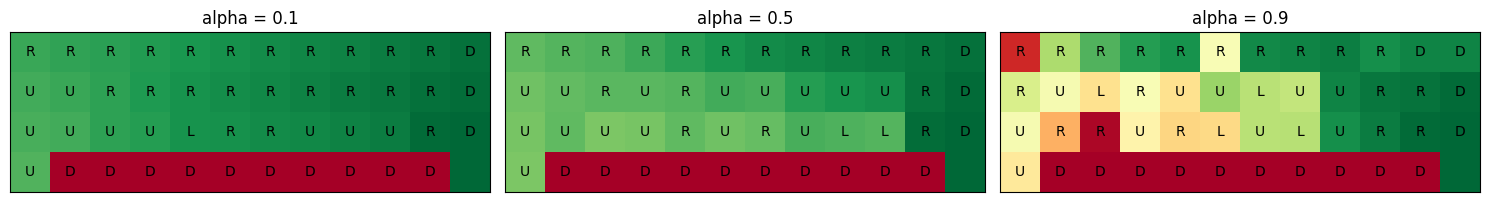

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, alpha in zip(axes, alphas):
    q = results[alpha]["q"]
    draw_value_matrix(q, ax=ax)
    ax.set_title(f"alpha = {alpha}")

plt.tight_layout()
plt.show()


Acá podemos ver que con un valor bajo, como $\alpha=0.1$, el agente demuestra la mejor calidad de aprendizaje, logrando estimaciones de valor estables que lo guían a tomar las decisiones óptimas en la mayoría de las situaciones. El aprendizaje es gradual y robusto, evitando ser perturbado por el ruido de la exploración.

Al incrementar $\alpha$ a un nivel de 0.5, la matriz es en gran medida similar, lo que indica que el camino seguro se mantiene, aunque los valores numéricos absolutos para algunas celdas pueden diferir debido al mayor peso dado a las experiencias recientes.

Finalmente, al utilizar un valor de $\alpha$ elevado, observamos la consecuencia de un aprendizaje acelerado: si bien las áreas cercanas al objetivo, que son más determinísticas, parecen haber entrenado correctamente, las estimaciones de valor en las etapas iniciales del recorrido se vuelven inestables e inconsistentes.


Observemos ahora lo que sucede al cambiar el parámetro $\gamma$, pero manteniendo $\alpha = 0.5$ y $\epsilon= 0.1$.

$\gamma$ es un parámetro llamado "factor de descuento" y determina la importancia de las recompensas futuras en el cálculo del valor de la acción actual.

- Si $\gamma = 1$, busca la máxima recompensa total acumulada a lo largo de todo el episodio.

- Si $\gamma = 0$, busca la máxima recompensa instantánea. No planifica más allá del siguiente paso.

- En el medio, hay un equilibrio.

Elijamos los $\gamma$ a utilizar e instanciemos y ejecutemos el agente:

In [36]:
gammas = [0.1, 0.5, 1.0]

# Creamos un diccionario para guardar todos los resultados
results = {}

for gamma in gammas:
    avg_steps, timesteps_ep, reward_ep, q = instanciate_agent(
        alpha=0.5,
        gamma=gamma,
        epsilon=0.1,
        learning_function=learn_SARSA
    )
    results[gamma] = {
        "avg_steps": avg_steps,
        "timesteps": timesteps_ep,
        "reward": reward_ep,
        "q": q
    }

Ahora, grafiquemos la recompensa acumulada.

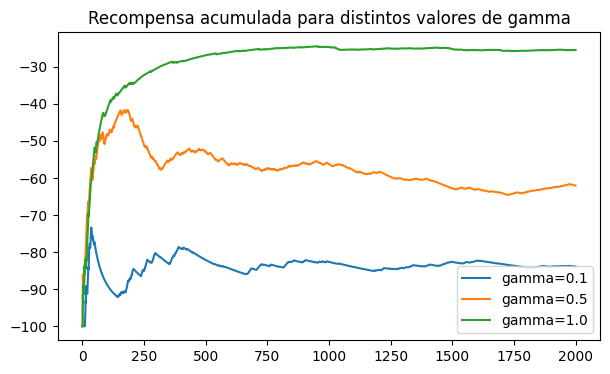

In [37]:
fig, ax = plt.subplots(figsize=(7,4))

for gamma in gammas:
    reward_ep = results[gamma]["reward"]
    # graficamos sobre el mismo eje
    plot_reward_per_episode(reward_ep, ax=ax, label=f"gamma={gamma}")

ax.set_title("Recompensa acumulada para distintos valores de gamma")
plt.show()

Podemos ver cómo al aumentar el $\gamma$, la recompensa total acumulada aumenta, ya que, justamente, si el parámetro el chico solo importa la decisión actual.

Veamos ahora los pasos por episodio.

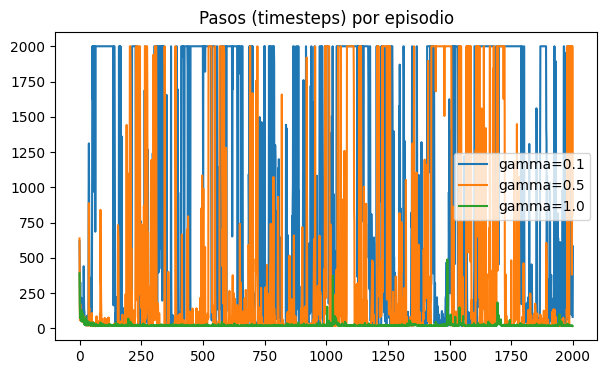

In [38]:
fig, ax = plt.subplots(figsize=(7,4))

for gamma in gammas:
    timesteps_ep = results[gamma]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode(
        timesteps_ep,
        ax=ax,
        label=f"gamma={gamma}"
    )

plt.show()


En este caso las fluctuaciones parecen ser gigantes. Veamos lo que sucede si suavizamos:

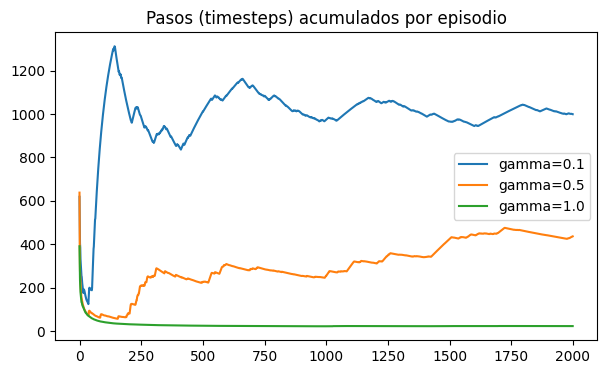

In [39]:
fig, ax = plt.subplots(figsize=(7,4))

for gamma in gammas:
    timesteps_ep = results[gamma]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode_smooth(
        timesteps_ep,
        ax=ax,
        label=f"gamma={gamma}"
    )

plt.show()


Puede verse cómo la única curva que se estabiliza cerca del 0 es para un valor alto de $\gamma$. Para los otros, como lo que más importa es el estado actual, cada celda puede cambiar mucho con respecto a su vecina.

Por último, veamos las matrices de acción-valor.

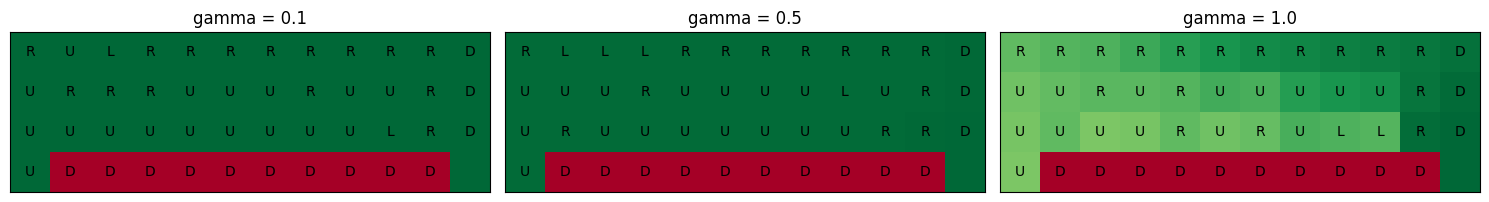

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, gamma in zip(axes, gammas):
    q = results[gamma]["q"]
    draw_value_matrix(q, ax=ax)
    ax.set_title(f"gamma = {gamma}")

plt.tight_layout()
plt.show()


En este caso podemos ver que el valor de $Q$ para $\gamma$ chico parece ser parecido en todas las celdas mientras que para $\gamma=1$ al comienzo el valor de $Q$ es bajo y luego crece, ya que al principio se busca un paso que optimice el camino completo y no solo cada celda particular.


Por último, veamos lo que sucede al variar $\epsilon$ y manteniendo $\alpha = 0.5$ y $\gamma= 1.0$.

Al variar el $\epsilon$, no estamos variando un parámetro correspondiente a SARSA sino que corresponde a $\epsilon$-greedy y nos dice si el modelo es muy explorador ó explotador. Si $\epsilon → 0$, el modelo tiende a ser explotador e intenta seguir siempre el camino óptico pero puede ignorar caminos por no explorarlos. Si $\epsilon → 1$, el modelo solo explora sin ver el camino óptimo, siguiendo casi una caminata aleatoria.

Elijamos los $\epsilon$ a utilizar e instanciemos y ejecutemos el agente:

In [41]:
epsilons = [0.001, 0.1, 0.8]

# Creamos un diccionario para guardar todos los resultados
results = {}

for epsilon in epsilons:
    avg_steps, timesteps_ep, reward_ep, q = instanciate_agent(
        alpha=0.5,
        gamma=1.0,
        epsilon=epsilon,
        learning_function=learn_SARSA
    )
    results[epsilon] = {
        "avg_steps": avg_steps,
        "timesteps": timesteps_ep,
        "reward": reward_ep,
        "q": q
    }

Ahora, grafiquemos la recompensa acumulada.

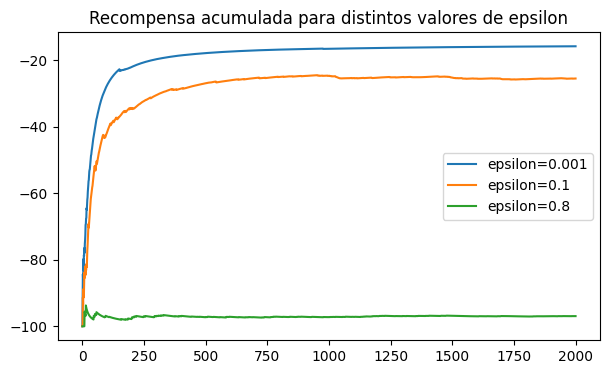

In [42]:
fig, ax = plt.subplots(figsize=(7,4))

for epsilon in epsilons:
    reward_ep = results[epsilon]["reward"]
    # graficamos sobre el mismo eje
    plot_reward_per_episode(reward_ep, ax=ax, label=f"epsilon={epsilon}")

ax.set_title("Recompensa acumulada para distintos valores de epsilon")
plt.show()

Podemos ver cómo al aumentar el $\epsilon$, la recompensa total acumulada decrece.

Veamos ahora los pasos por episodio.

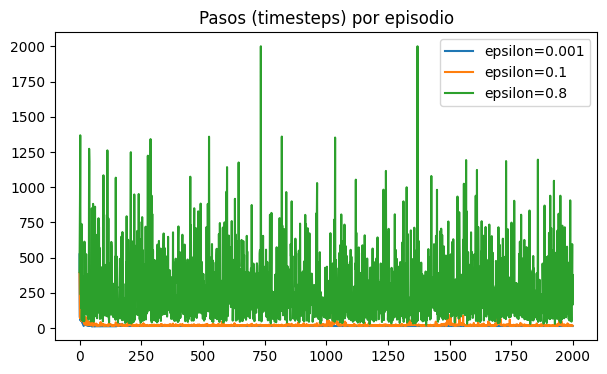

In [43]:
fig, ax = plt.subplots(figsize=(7,4))

for epsilon in epsilons:
    timesteps_ep = results[epsilon]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode(
        timesteps_ep,
        ax=ax,
        label=f"epsilon={epsilon}"
    )

plt.show()


En este caso también hay fluctuaciones muy grandes cuando el $\epsilon$ es grande, ya que en ese caso es todo muy aleatorio. Veamos si suavizamos:

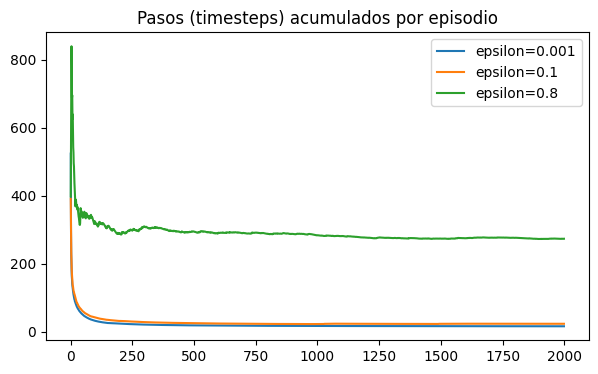

In [44]:
fig, ax = plt.subplots(figsize=(7,4))

for epsilon in epsilons:
    timesteps_ep = results[epsilon]["timesteps"]
    # graficamos sobre el mismo eje
    plot_steps_per_episode_smooth(
        timesteps_ep,
        ax=ax,
        label=f"epsilon={epsilon}"
    )

plt.show()


Podemos ver, como era de esperar, que al disminuir el parámetro, los pasos se estabilizan más cerca de 0.

Por último, veamos las matrices de acción-valor.

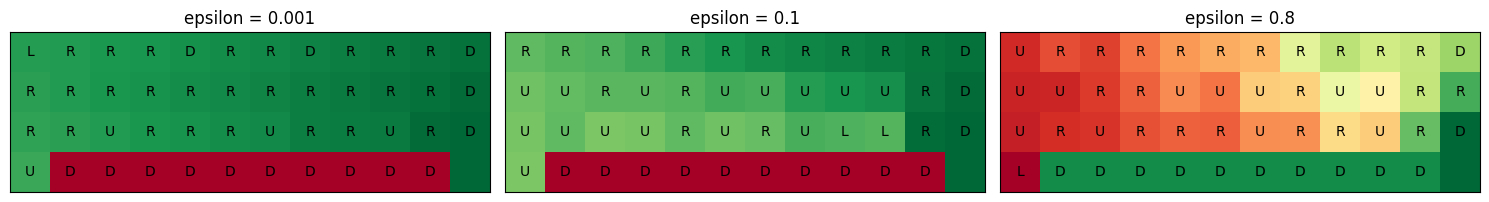

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, epsilon in zip(axes, epsilons):
    q = results[epsilon]["q"]
    draw_value_matrix(q, ax=ax)
    ax.set_title(f"epsilon = {epsilon}")

plt.tight_layout()
plt.show()


Acá podemos ver cómo para el caso de $\epsilon$ muy bajo, parece que empezó abajo a la izquierda y encontró un camino que llegaba hasta el final pero que no es ni el más seguro ni el óptimo y, como en este caso casi no hay exploración, sigue siempre el mismo camino sin intentar otro como sí lo hace cuando $\epsilon=0.1$. Cuando el $\epsilon$ se hace muy grande, el agente se mueve casi de forma aleatoria, tomando decisiones que carecen de sentido en algunos casos.


Como estos parámetros varían al utilizar Q-learning funciona de una forma similar ya que están definidos de la misma forma.